In [1]:
import rasterio

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
#load data
path_2018_B04 = "../data/raw/satellite/merged/2018/2018_B04_harz.tif"
path_2018_B08 = "../data/raw/satellite/merged/2018/2018_B08_harz.tif"
path_2023_B04 = "../data/raw/satellite/merged/2023/2023_B04_harz.tif"
path_2023_B08 = "../data/raw/satellite/merged/2023/2023_B08_harz.tif"
path_2026_B04 = "../data/raw/satellite/merged/2026/2026_B04_harz.tif"
path_2026_B08 = "../data/raw/satellite/merged/2026/2026_B08_harz.tif"

def get_image_data(path):

    with rasterio.open(path) as src:
        data = src.read(1)
        data[data == 0] = np.nan 
        return data, src

data_2018_B04, metadata_2018_B04 = get_image_data(path_2018_B04)
data_2018_B08, metadata_2018_B08 = get_image_data(path_2018_B08)
data_2023_B04, metadata_2023_B04 = get_image_data(path_2023_B04)
data_2023_B08, metadata_2023_B08 = get_image_data(path_2023_B08)
data_2026_B04, metadata_2026_B04 = get_image_data(path_2026_B04)
data_2026_B08, metadata_2026_B08 = get_image_data(path_2026_B08)

In [4]:
#check metadata
(metadata_2018_B04.shape == metadata_2018_B08.shape) & (metadata_2018_B04.crs == metadata_2018_B08.crs) & (metadata_2018_B04.transform == metadata_2018_B08.transform)

True

In [5]:
metadata_2018_B04.shape == metadata_2023_B04.shape == metadata_2026_B04.shape

False

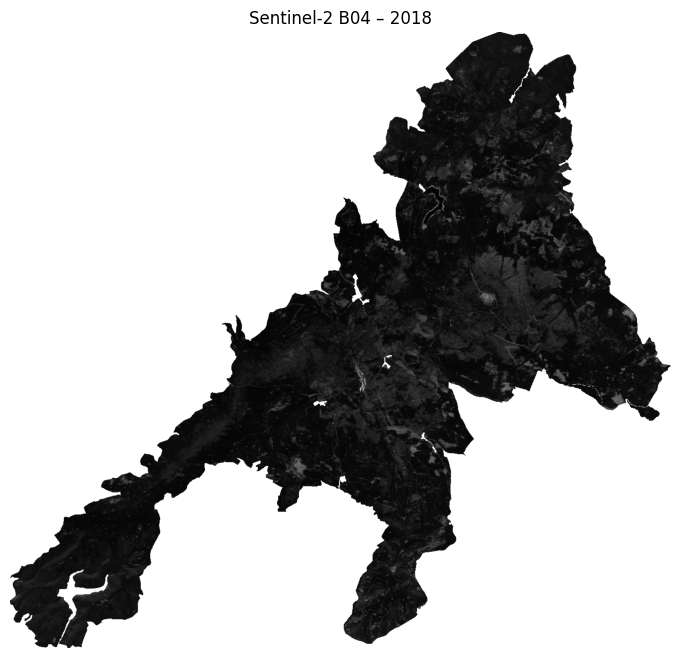

In [6]:
#plot of B04(meassured red light) in 2018
plt.subplots(figsize = (10, 8))
plt.title("Sentinel-2 B04 – 2018")
plt.axis("off")
plt.imshow(data_2018_B04, cmap="gray")

Text(0.5, 0.98, 'Comparison of B04 in the years 2018, 2023 and 2026')

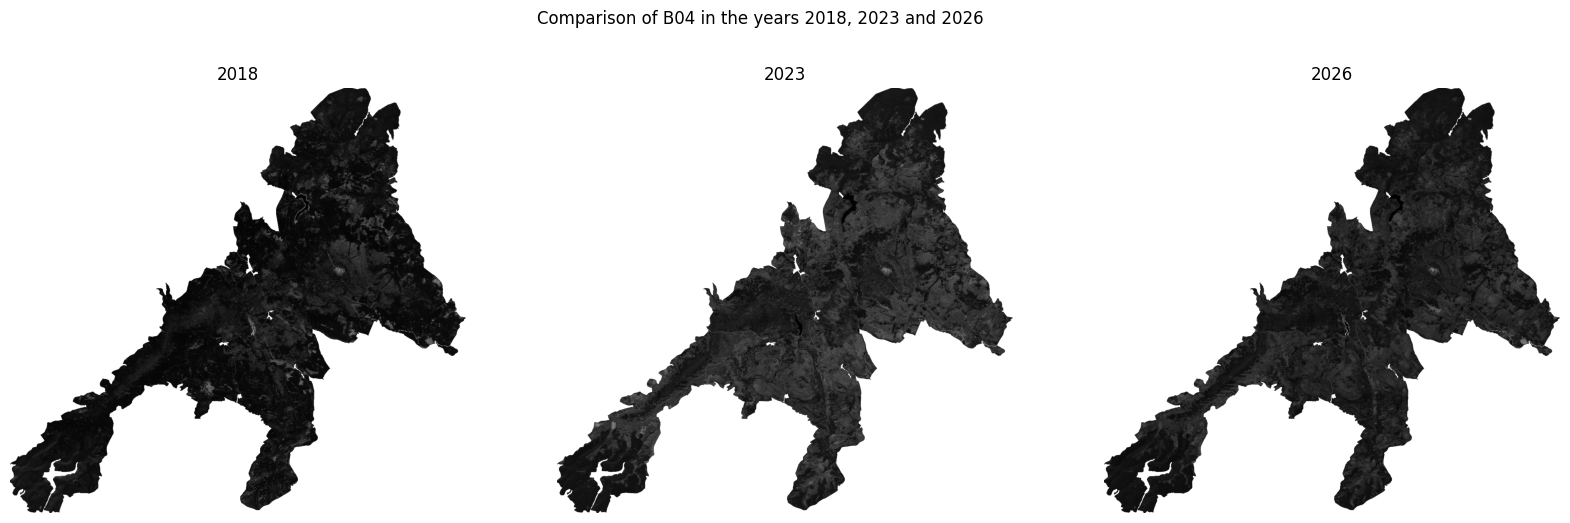

In [7]:
#comparing the 3 years
fig, axes = plt.subplots(1, 3, figsize = (20, 6))

axes[0].imshow(data_2018_B04, cmap="gray")
axes[1].imshow(data_2023_B04, cmap="gray")
axes[2].imshow(data_2026_B04, cmap="gray")

axes[0].axis("off")
axes[1].axis("off")
axes[2].axis("off")

axes[0].set_title("2018")
axes[1].set_title("2023")
axes[2].set_title("2026")

fig.suptitle("Comparison of B04 in the years 2018, 2023 and 2026")

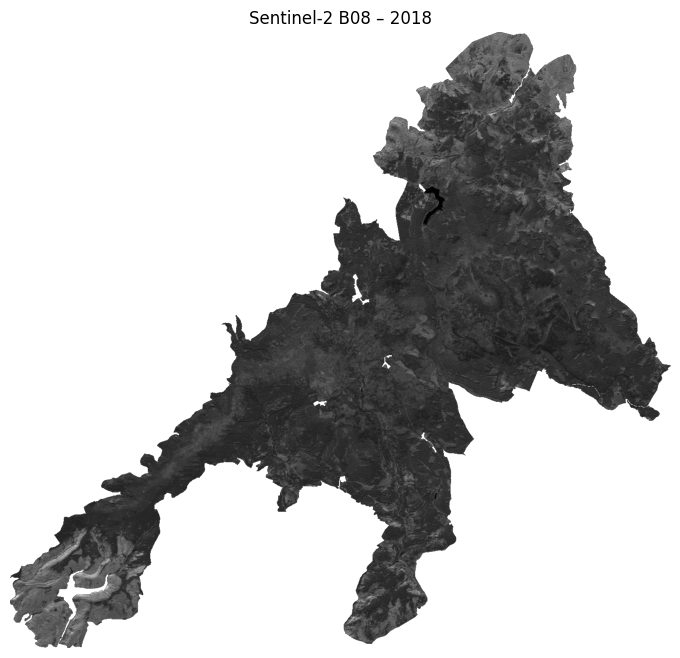

In [8]:
#plot of B08(meassured near-infrared light) in 2018
plt.subplots(figsize = (10, 8))
plt.title("Sentinel-2 B08 – 2018")
plt.axis("off")
plt.imshow(data_2018_B08, cmap="gray")

Text(0.5, 0.98, 'Comparison of B08 in the years 2018, 2023 and 2026')

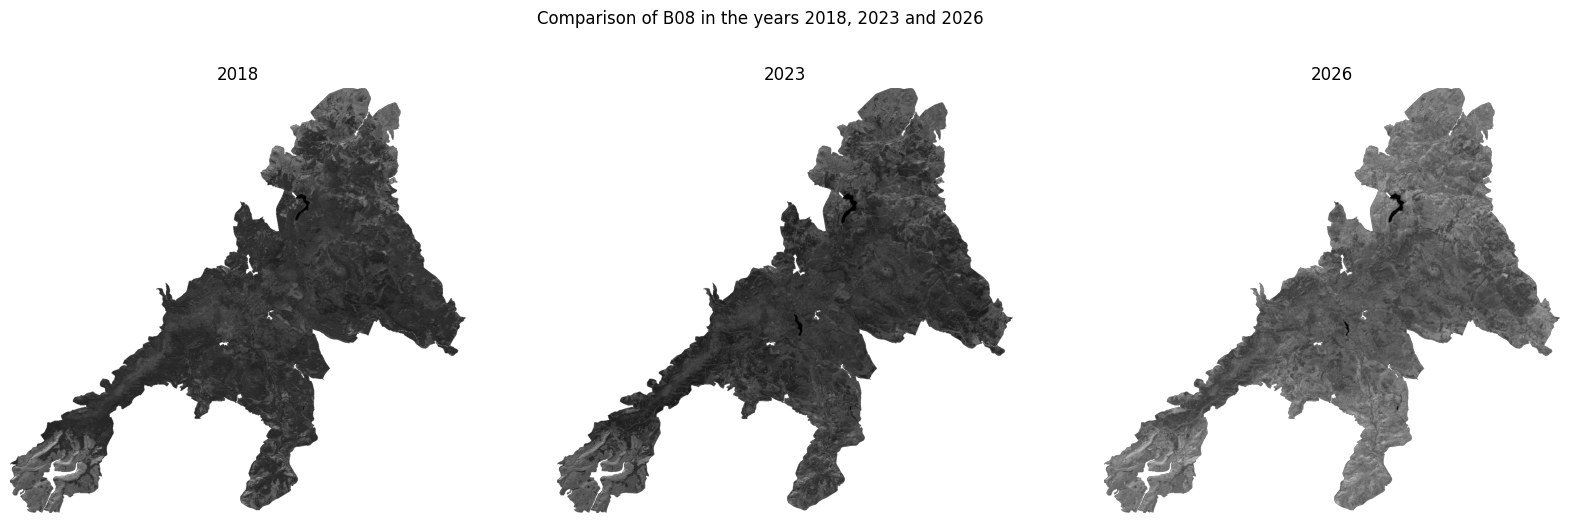

In [9]:
#comparing the 3 years
fig, axes = plt.subplots(1, 3, figsize = (20, 6))

axes[0].imshow(data_2018_B08, cmap="gray")
axes[1].imshow(data_2023_B08, cmap="gray")
axes[2].imshow(data_2026_B08, cmap="gray")

axes[0].axis("off")
axes[1].axis("off")
axes[2].axis("off")

axes[0].set_title("2018")
axes[1].set_title("2023")
axes[2].set_title("2026")

fig.suptitle("Comparison of B08 in the years 2018, 2023 and 2026")

In [10]:
#Calculating NDVI
def calculate_ndvi(nir, red):
    ndvi = (nir - red) / (nir + red)
    return ndvi

ndvi_2018 = calculate_ndvi(data_2018_B08, data_2018_B04)
ndvi_2023 = calculate_ndvi(data_2023_B08, data_2023_B04)
ndvi_2026 = calculate_ndvi(data_2026_B08, data_2026_B04)

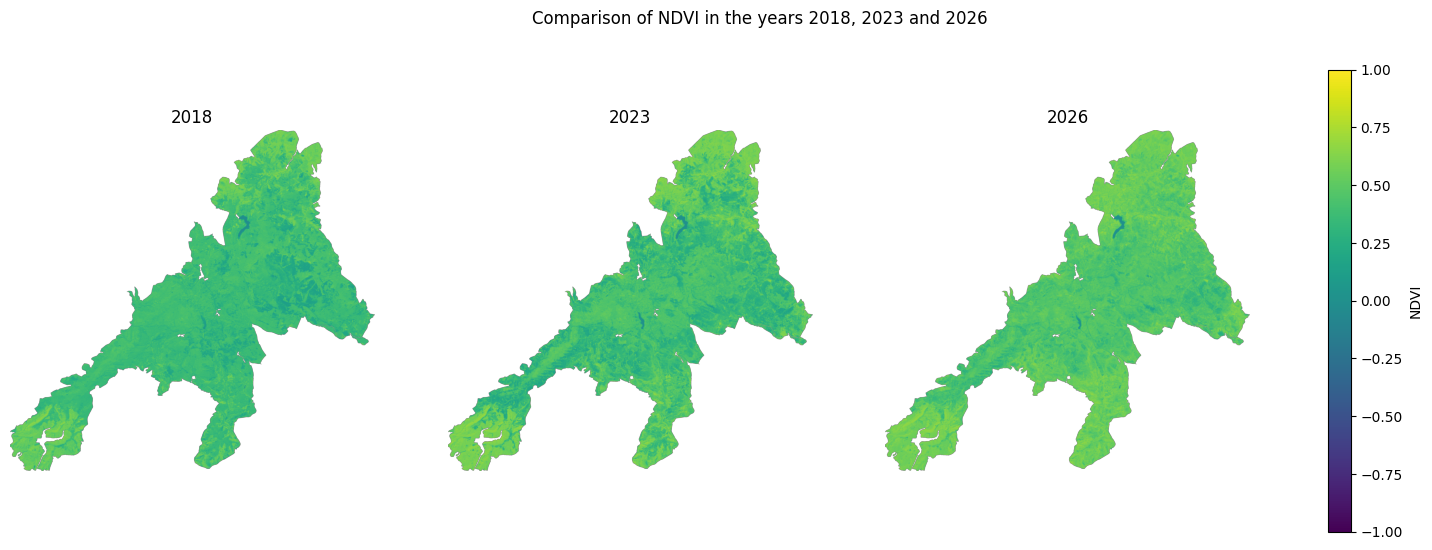

In [71]:
#Plotting different NDVIs
fig, axes = plt.subplots(1, 3, figsize = (20, 6))

im = axes[0].imshow(ndvi_2018, vmin=-1, vmax=1)
axes[1].imshow(ndvi_2023, vmin=-1, vmax=1)
axes[2].imshow(ndvi_2026, vmin=-1, vmax=1)

axes[0].axis("off")
axes[1].axis("off")
axes[2].axis("off")

axes[0].set_title("2018")
axes[1].set_title("2023")
axes[2].set_title("2026")

fig.suptitle("Comparison of NDVI in the years 2018, 2023 and 2026")
fig.colorbar(im, ax=axes, label="NDVI")

In [ ]:
np.nanmean(ndvi_2018), np.nanmean(ndvi_2023), np.nanmean(ndvi_2026)

#Over the last years the NDVI actually increased. Thats because the NDVI is a measurement for healthy green vegetation not trees only.
#When looking at the satellite pictures this is actually the case. Over the years the picture has become more green, while most of the forest area decreased

(np.float32(0.37940094), np.float32(0.41607377), np.float32(0.47955143))

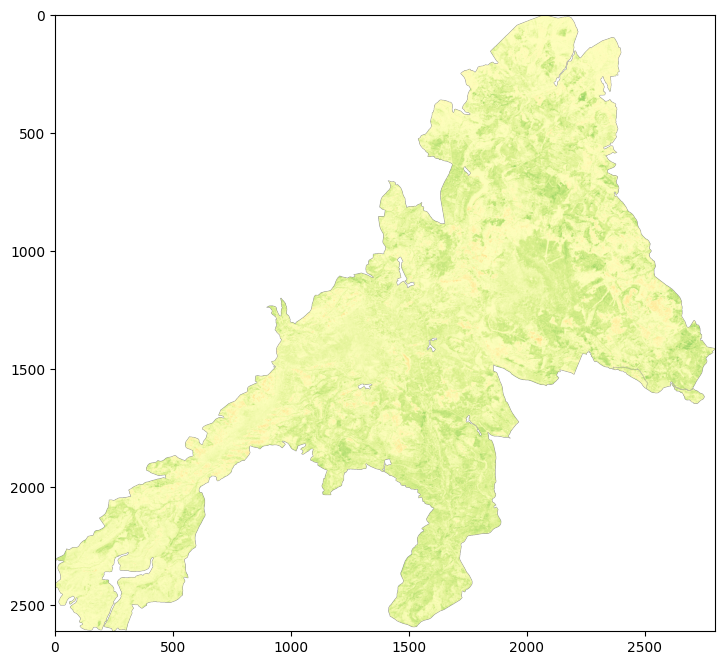

In [53]:
ndvi_change_18_26 = ndvi_2026 - ndvi_2018

plt.figure(figsize=(10, 8))

plt.imshow(
    ndvi_change_18_26,
    cmap="RdYlGn",
    vmin=-1,
    vmax=1
)